In [1]:
from rpgpy import rpg2nc
import numpy as np
from gfatpy.radar.rpg_nc import rpg
from pathlib import Path
import matplotlib.pyplot as plt

from IPython import get_ipython

plt.close('all')
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

In [2]:
path_lv1 = "../../../radar_data/RAW/nebula_w/2024/04/20/240420_153025_P00_PPI.LV1"
path_nc = "../../../radar_data/PRODUCTS/nebula_w/2024/04/20/240420_153025_P00_PPI.LV1.nc"

rpg2nc(path_lv1, path_nc) # if the file already exists, it might give an error message
                          # The error is associated with the fact that the file already exists
                          # and the function has no permission to overwrite it. 
                          # In this case, I suggest to add some lines to verify if the file exists
                          # and if dont, create it. Otherwise just skip the conversion.


In [3]:
radar = rpg(Path(path_nc))

In [4]:
radar.__dict__

{'path': PosixPath('../../../radar_data/PRODUCTS/nebula_w/2024/04/20/240420_153025_P00_PPI.LV1.nc'),
 'type': 'PPI',
 'level': 1,
 'raw': <xarray.Dataset>
 Dimensions:                          (range: 338, time: 243)
 Coordinates:
   * time                             (time) datetime64[ns] 2024-04-20T15:30:2...
   * range                            (range) float32 102.2 127.8 ... 1.197e+04
 Data variables: (12/65)
     file_code                        int32 ...
     header_length                    int32 ...
     program_number                   int32 ...
     model_number                     int32 ...
     radar_frequency                  float32 ...
     antenna_separation               float32 ...
     ...                               ...
     correlation_coefficient          (time, range) float32 ...
     differential_phase               (time, range) float32 ...
     ldr_slanted                      (time, range) float32 ...
     correlation_coefficient_slanted  (time, range) flo

In [5]:
# radar.data is an xarray dataset with the variables in the LV1 file
radar.data

<xarray.Dataset>
Dimensions:                          (range: 338, time: 243)
Coordinates:
  * time                             (time) datetime64[ns] 2024-04-20T15:30:2...
  * range                            (range) float32 102.2 127.8 ... 1.197e+04
Data variables: (12/67)
    file_code                        int32 ...
    header_length                    int32 ...
    program_number                   int32 ...
    model_number                     int32 ...
    radar_frequency                  float32 ...
    antenna_separation               float32 ...
    ...                               ...
    ldr_slanted                      (time, range) float32 ...
    correlation_coefficient_slanted  (time, range) float32 ...
    differential_phase_shift         (time, range) float32 ...
    differential_attenuation         (time, range) float32 ...
    dBZe                             (time, range) float32 18.12 18.41 ... nan
    specific_differential_phase      (time, range) float32 1.585 1.585 ... nan
Attributes:
    Conventions:       CF-1.7
    year:              2024
    month:             04
    day:               20
    uuid:              ba7baa0aa27c4d43a1c1396c7974c5bd
    rpgpy_version:     0.15.8
    rpg_file_version:  4.0
    history:           Radar file created: 2024-09-03 14:44:32
    level:             1

/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/matheustolen/Documentos/matheus_doctorado/phd-clouds/.venv/lib/python3.10/site-packages/gfatpy/radar/rpg_nc.py:593: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in

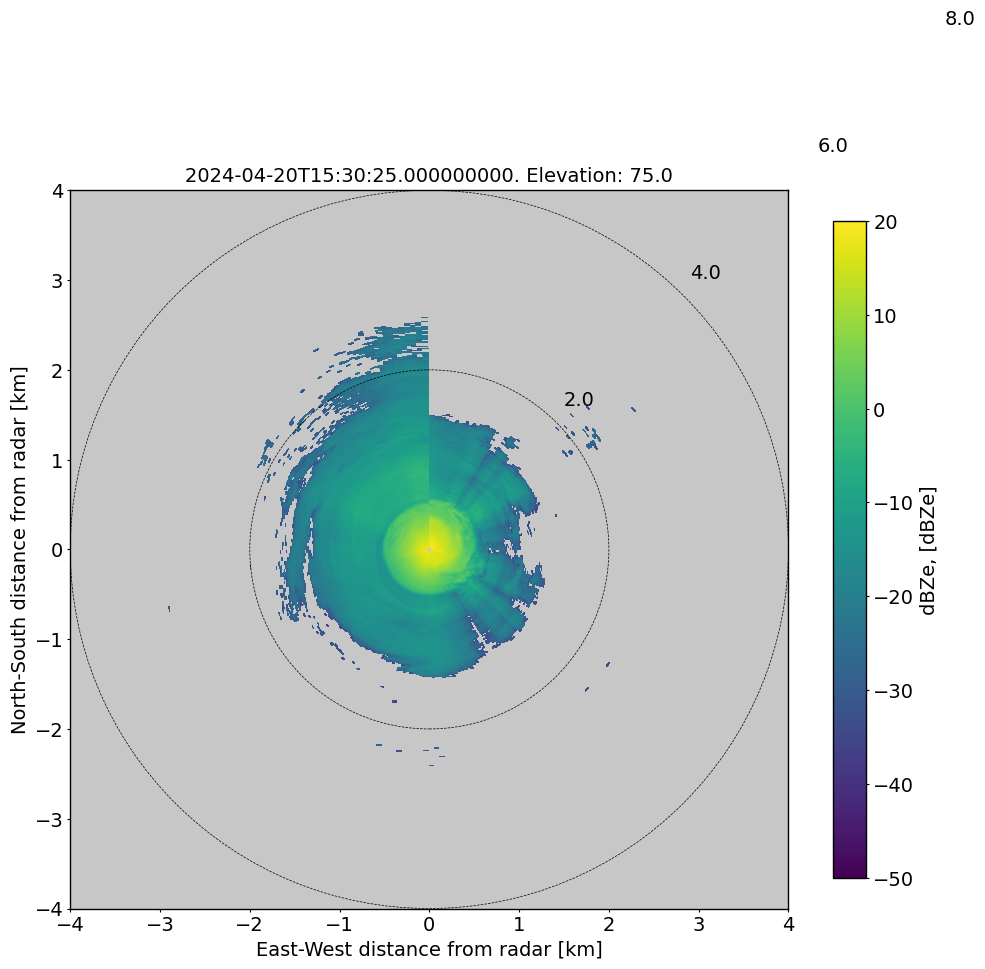

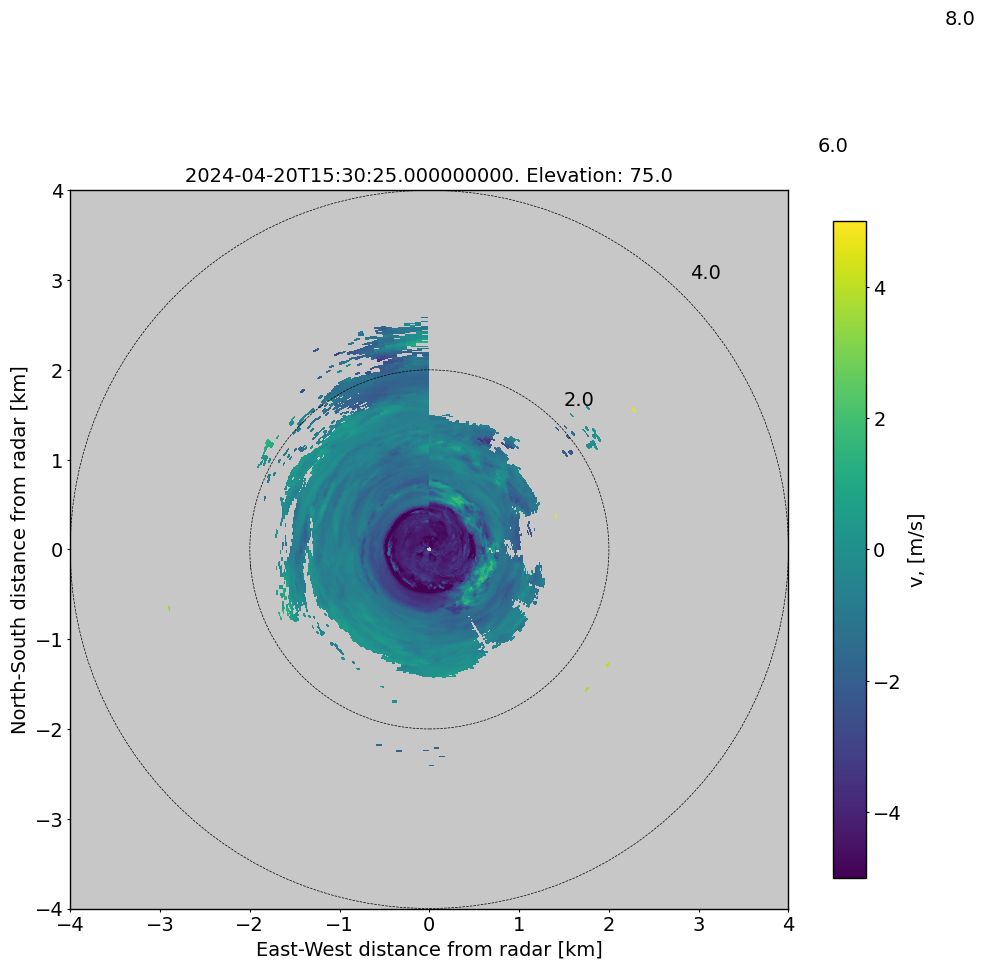

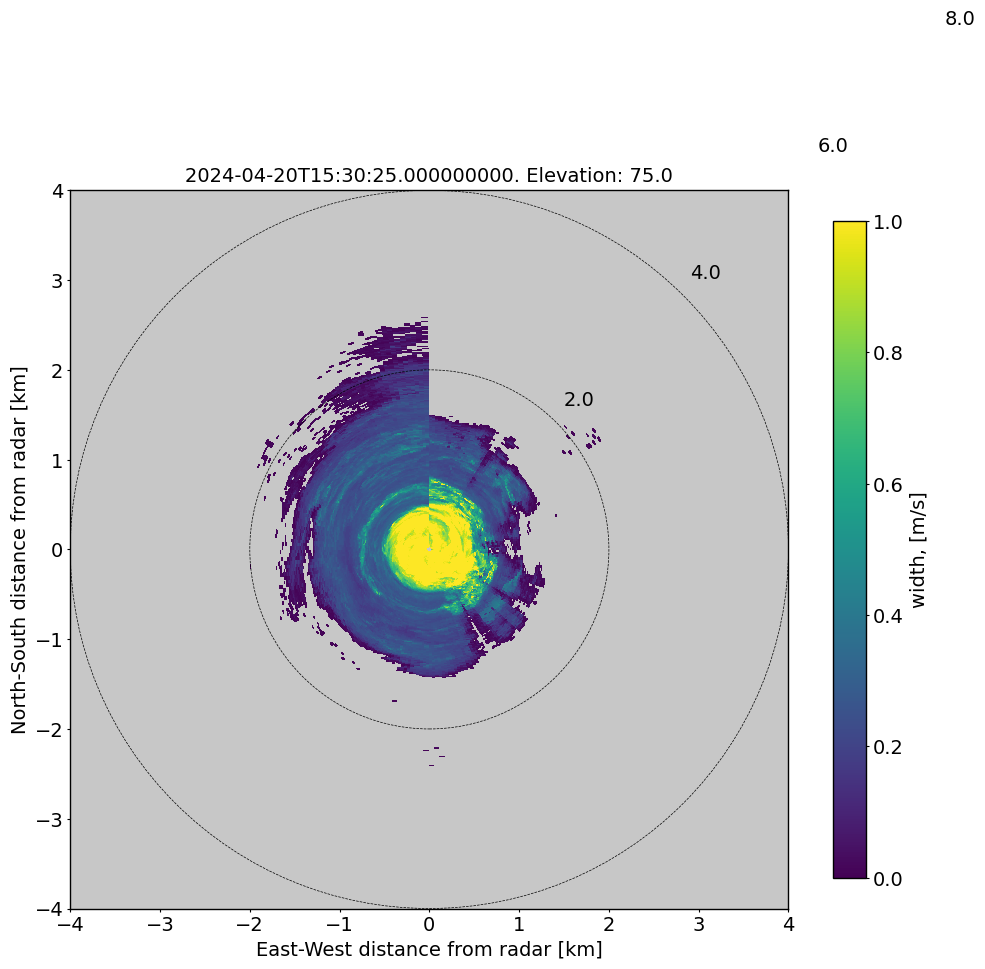

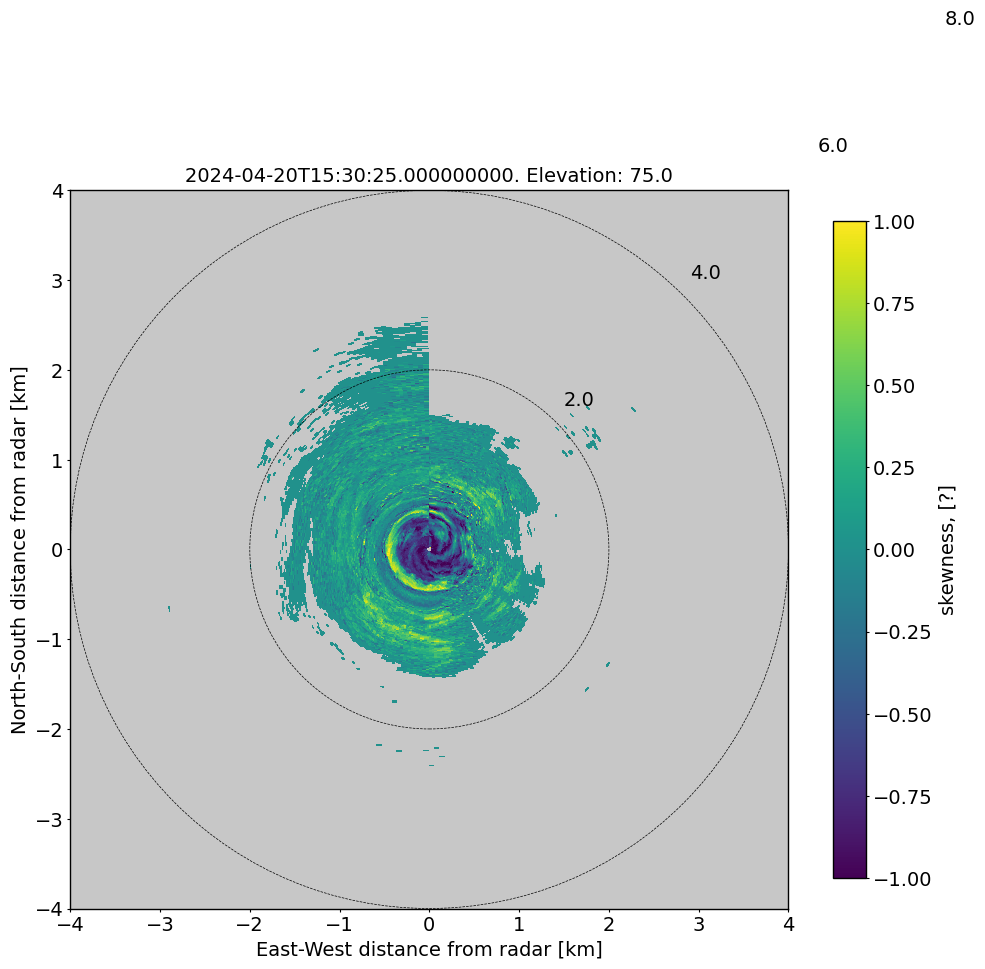

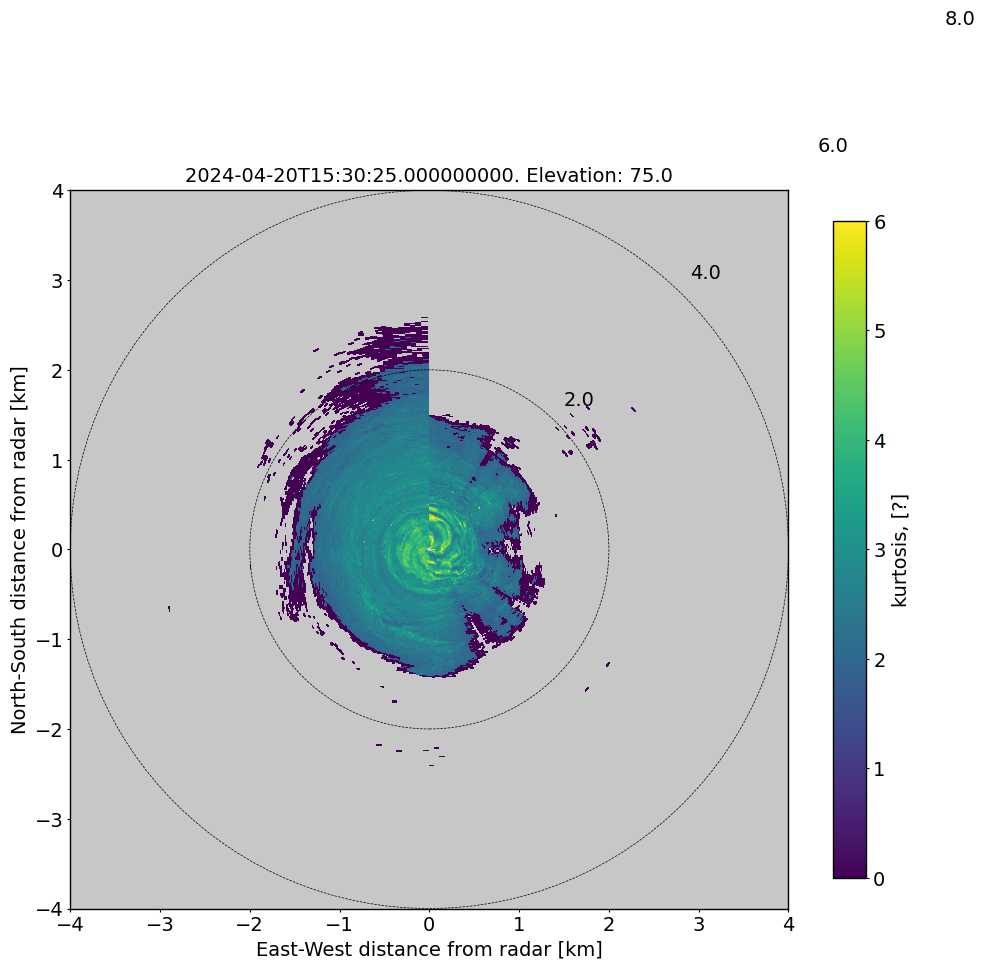

In [7]:
figure_folder = "./"
try:
    if radar.level == 1 and radar.type == "PPI":
        figs, filepath = radar.plot_ppi(
            variable=[
                "dBZe",
                "v",
                "width",
                "skewness",
                "kurtosis",
            ],
            dpi=400,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
        for fig in figs:
            fig.axes[0].set_xlim(-4, 4)
            fig.axes[0].set_ylim(-4, 4)
except Exception as e:
    print(e)

In [ ]:
figure_folder = "./"
try:
    if radar.level == 1 and radar.type == "ZEN":
        figs, filepath = radar.plot_zen(
            variable=[
                "dBZe",
                "v",
                "width",
                "skewness",
                "kurtosis",
            ],
            range_limits=[0, 12],
            dpi=400,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
except Exception as e:
    print(e)

In [ ]:
figure_folder = "./"
try:
    if radar.level == 1 and radar.type == "RHI":
        figs, filepath = radar.plot_rhi(
            variable=[
                "dBZe",
                "v",
                "width",
                "skewness",
                "kurtosis",
            ],
            dpi=400,
            savefig=False,
            output_dir=figure_folder,
            **{"cmap":"jet"},
        )
except Exception as e:
    print(e)